# Анализ результатов А/В-теста

## Описание проекта

Данный проект также размещен на платформе Kaggle: [A/B-test analysis](https://www.kaggle.com/code/alenakn/a-b-test-analysis/notebook)

Проект основывается на датасете "Cookie Cats Dataset", который доступен на [kaggle](https://www.kaggle.com/code/yufengsui/datacamp-project-mobile-games-a-b-testing/input).

Игра "Cookie Cats" была разработана компанией "Tactile Games". Она в настоящий момент имеет более 1 миллиона скачиваний на [Google Play](https://play.google.com/store/apps/details?id=dk.tactile.cookiecats), отзывы в основном положительные.

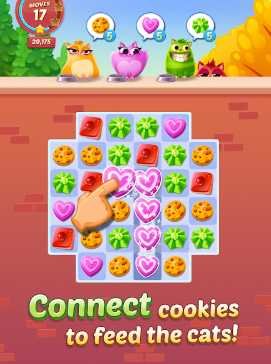

Монетизация приложения построена следующим образом. По мере прохождения уровней игры игроки время от времени сталкиваются с барьерами, которые вынуждают их либо ждать довольно долгое время, либо совершить внутриигровую покупку для продолжения. Прежде всего, эта функция стимулирует внутриигровые покупки. Но также такие барьеры также дают игрокам вынужденный перерыв в игре. Это приводит к повышению показателей удержания игроков, поскольку у них нет возможности пройти игру сразу.

Данный А/В-тест напарвлен на то, чтобы определить, на какойм уровне лучше поставить первый барьер. Изначально первый барьер был установлен на 30-ом уровне. Было предложено перенести первый барьер с 30-го на 40-ой уровень, чтобы улучшить показатели удержания пользователей.

**Гипотезы**:

H0 (Нулевая гипотеза): Перемещение первого барьера с 30-го на 40-ой уровень не повлияет на метрику 7-Day Retention.

H1 (Альтернативная гипотеза): Перемещение первого барьера с 30-го на 40-ой уровень повлияет на метрику 7-Day Retention (двусторонняя альтернатива).

## Импорт библиотек и выгрузка данных

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import math

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ElenaNKn/data_projects_ru/refs/heads/master/project_ab_testing/cookie_cats.csv')

In [3]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
# проверка на наличие пропусков
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [5]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


Стандартное отклонение показателя `sum_gamerounds` достаточно большое, а максимальное значение значительно превышает 75% перцентиль. Это может указывать на наличие проблем с данными

In [6]:
df.sum_gamerounds.value_counts().reset_index().sort_values('sum_gamerounds', ascending = False).head(7)

,sum_gamerounds,count
874,49854,1
855,2961,1
736,2640,1
810,2438,1
831,2294,1
818,2251,1
732,2156,1


Похоже, что пользователь, у которого `'sum_gamerounds' = 49854` является тестовым: его показатель количества пройденных уровней `sum_gamerounds` значительно превышает аналогичный показатель у остальных игроков. Поскольку поведение данного пользователя не является типичным, исключим его.

In [7]:
df = df[df['sum_gamerounds'] != 49854]

## Дизайн эксперимента

Изначально исследуемый датасет использовался в мини-проекте на DataCamp, и данный проект не предполагал наличие этапа дизайна эксперимента. Ученики должны были просто проверить наличие статзначимого отличие по метрике между двумя вариантами. Однако при работе с реальными данными дизайн эксперимента является важнейшим этапом и включает в себя, как минимум, определение целевой метрики и расчет размера выборки.

Предположим, посредством перемещения барьера с 30-го на 40-ой уровень мы хотим повысить 7-Day Retention. Тогда исследуемыми метриками являются:
- **целевая метрика** (метрика которую мы хотим повысить) - 7-Day Retention;
- **барьерная метрика** (метрика, которая призвана предотвратить негативный эффект от эксперимента, т.е. мы ни в коем слечае не должны ее уронить) - 1-Day Retention

Теперь зафиксируем эффект, который мы бы хотели отследить и рассчитаем размер групп. В реальности мы бы для этого использовали исторические данные. Но поскольку в данном датасете у нас нет такой возможности, выполним оценку 7-day Retention на базе контрольной группы (группы с параметром `version = 'gate_30'`)

In [8]:
point_est = df[(df.version == 'gate_30') & (df.retention_7)].shape[0] / df[df.version == 'gate_30'].shape[0]
point_est

0.19018322557551623

Допустим мы ожидаем, что перенос барьера позволит повысить 7-day Retention c 19% до 20% и мы бы хотели отслеживать этот эффект с 95% вероятностью. Тогда размер группы может быть рассчитан с помощью следующей функции:

In [9]:
def sample_size(
    baseline_rate=0.19,
    expected_lift=0.01,
    alpha=0.05,      # уровень значимости - alpha
    power=0.80,      # 1 - beta
    alternative='two-sided'
):
    """
    Sample size per group for a A/B test.
    
    Parameters:
    - baseline_rate: historical 
    - expected_lift: expected absolute increase of rate
    - alpha: confidence level 
    - power: statistical power (default 0.80)
    - alternative: 'two-sided' or 'one-sided'
    
    Returns:
    - n_samples: required sample size per variant
    """
    p1 = baseline_rate
    p2 = baseline_rate + expected_lift
    
    p_pool = (p1 + p2) / 2
    
    if alternative == 'two-sided':
        z_alpha = stats.norm.ppf(1 - alpha/2)
    else:  
        z_alpha = stats.norm.ppf(1 - alpha)
    
    z_beta = stats.norm.ppf(power)
    
    # формула размера выборки для бинарной метрики
    # n = (z_alpha * sqrt(2 * p_pool * (1 - p_pool)) + z_beta * sqrt(p1*(1-p1) + p2*(1-p2)))^2 / (p2 - p1)^2
    n_numerator = (z_alpha * math.sqrt(2 * p_pool * (1 - p_pool)) +
                 z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    n_denominator = (p2 - p1) ** 2
    
    n_samples = math.ceil(n_numerator / n_denominator)
    
    return n_samples

In [10]:
n_samples = sample_size(
    baseline_rate=point_est,
    expected_lift=0.01,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

print(f"Размер группы: {n_samples}")
print(f"Общий размер выборки: {n_samples * 2}")

Размер группы: 24658
Общий размер выборки: 49316


Проверим количество наблюдений в исследуемом датасете

In [11]:
df.groupby('version').agg(
    users = ('userid', 'nunique')
)

,users
version,
gate_30,44699
gate_40,45489


Исследуемый датасет намного больше, чем нам требуется. В большинстве случаев `userid` присваивается пользователю сразу после регистрации. Чем больше величина `userid`, тем позже пользователь зарегистрировался. Поэтому мы можем сформировать наши группы, взяв n_samples наименьших `userid` для каждого варианта (варианты определяются параметром `version`, соответствующим положению барьера).

*В реальности часто надо взять несколько большую выборку, так как может понадобиться очистка от выбросов (например, с применением методов MDE или полуторного интерквантильного размаха). Но метрики, применяемые в данном тесте не требуют очистки*

In [12]:
group_a = df[df.version == 'gate_30'].sort_values('userid').head(25000)
group_b = df[df.version == 'gate_40'].sort_values('userid').head(25000)

In [13]:
group_a.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
6,1066,gate_30,0,False,False
11,2101,gate_30,0,False,False
13,2179,gate_30,39,True,False


## Проверка однородности

В реальныз датасетах обусчно требуется проверить однородность данных по различным признакам, например, по свойствам пользователей. Мы должны убедиться, что для признаков, на которые эксперимент не влияет, наши группы A и B схожи на заданном уровне значимости.

В исследуемом наборе данных единственным признаком, который у нас есть, является количество уровней, пройденных пользователем (`gamerounds`). На уровне всего набора данных этот признак может подвергаться влиянию эксперимента. Однако для пользователей, которые не дошли до 30 уровня, наши группы A и B должны быть схожи. Поэтому мы можем проверить однородность пользователей из `group_a` и `group_b`, у которых количество пройденных уровней меньше 30 (в основном чтобы продемонстрировать тот факт, что проверку на однородность проводить следует).

Будем рассматривать количество пройденных уровней как категориальную величину, тогда для проверки ее однородности следует применять статистический критерий хи-квадрат. В другой строны, если рассматривать количество пройденных уровней как непрерывную величину (такой подход также обоснован), то проверку однородности лучше выполнять с помощью статистического критерия Колмагорова-Смирнова. Выполним проверку однородности по обоим подходам

**Критерий хи-квадрат**

In [14]:
from scipy.stats import chi2_contingency

df_check = df[(df.userid.isin(group_a.userid) | df.userid.isin(group_b.userid)) & (df.sum_gamerounds < 30)][['version', 'sum_gamerounds']] 

# Таблица сопряженности
contingency_table = pd.crosstab(
    df_check['version'],
    df_check['sum_gamerounds']
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Distributions are homogeneous: {'Yes' if p_value > 0.05 else 'No'}")

Chi-square statistic: 26.1951
P-value: 0.6150
Distributions are homogeneous: Yes


**Критерий Колмагорова-Смирнова**

In [15]:
from scipy.stats import ks_2samp

In [16]:
statistic, p_value = ks_2samp(group_a[group_a.sum_gamerounds < 30][['sum_gamerounds']], group_b[group_b.sum_gamerounds < 30][['sum_gamerounds']])
print(f"P-value: {p_value[0]:.4f}")
print(f"Distributions are homogeneous: {'Yes' if p_value > 0.05 else 'No'}")

P-value: 0.4888
Distributions are homogeneous: Yes


Таким образом, группы А и В однородны по признаку количества пройденных уровней в части сегмента пользователей, не достигших 30-го уровня.

## Анализ AB-теста

Целевая метрика (7-Day Retention) является бинарной. Для того, чтобы проверить, есть ли статистически значимая разница между вариантами в данном случае мы можем использовать двухвыборочный Z-критерий для долей или критерий хи-квадрат. В рассматриваемой задаче эти два подхода будут математически идентичны.

In [17]:
# двухвыборочный Z-критерий

from statsmodels.stats.proportion import proportions_ztest

n_a = len(group_a)
n_b = len(group_b)
retention_a = group_a['retention_7'].sum()
retention_b = group_b['retention_7'].sum()
rate_a = retention_a / n_a
rate_b = retention_b / n_b

count = np.array([retention_a, retention_b])
nobs = np.array([n_a, n_b])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z = {z_stat:.4f}, p-value = {p_value:.6f}")
print(f"There is a statistically significant difference: {'Yes' if p_value < 0.05 else 'No'}")
print(f"Point estimate of average 7-Day Retention for group A = {rate_a:.6f}")
print(f"Point estimate of average 7-Day Retention for group B = {rate_b:.6f}")

Z = 2.9621, p-value = 0.003056
There is a statistically significant difference: Yes
Point estimate of average 7-Day Retention for group A = 0.191680
Point estimate of average 7-Day Retention for group B = 0.181360


Из полученного результата мы видим, что разница по 7-Day Retention между группой A (где барьер был установлен на 30-ом уровне) и группой B (где барьер на 40-ом уровне) является статистически значимой. Перемещение барьера с 30-го на 40-ой уровень привело к снижению 7-Day Retention c 19.17% до 18.14%

Далее проверим барьерную метрику 1-Day Retention. В данном случае также использваем двухвыборочный Z-критерий

In [18]:
n_a = len(group_a)
n_b = len(group_b)
retention_a = group_a['retention_1'].sum()
retention_b = group_b['retention_1'].sum()
rate_a = retention_a / n_a
rate_b = retention_b / n_b

count = np.array([retention_a, retention_b])
nobs = np.array([n_a, n_b])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z = {z_stat:.4f}, p-value = {p_value:.6f}")
print(f"There is a statistically significant difference: {'Yes' if p_value < 0.05 else 'No'}")
print(f"Point estimate of average 1-Day Retention for group A = {rate_a:.6f}")
print(f"Point estimate of average 1-Day Retention for group B = {rate_b:.6f}")

Z = 1.0975, p-value = 0.272403
There is a statistically significant difference: No
Point estimate of average 1-Day Retention for group A = 0.448760
Point estimate of average 1-Day Retention for group B = 0.443880


Таким образом, перемещение барьера с 30-го на 40-ой уровень не оказало статистически значимого влияния на 1-Day Retention (при 95% уровне значимости).

## Выводы

1. A/B-тест был разработан на основе следующих исходных допущений:
   -  мы хотим повысить 7-Day Retention, перенеся первый барьер с 30-го уровня на 40-й;
   -  исследуемые метрики - это 7-Day Retention (целевая метрика) и 1-Day Retention (барьерная метрика — метрика, которую нельзя ронять);
   -  мы ожидаем, что благодаря предложенным изменениям 7-Day Retention вырастет с 19% до 20%, и мы хотим обнаружить этот рост с вероятностью 95%.
2. Проверка однородности показала, что пользователи, не достигшие 30-го уровня, вели себя схоже в группах A и B (группы однородны по показателю количества пройденных пользователями уровней).
3. Анализ результатов A/B-теста показал, что перенос барьера с 30-го уровня на 40-й не повлиял на 1-Day Retention, но привёл к статистически значимому снижению 7-Day Retention с 19,17% до 18,14%.